In [25]:
import numpy as np
np.int = int

import configparser
configparser.SafeConfigParser = configparser.ConfigParser

import pandas as pd
import matplotlib.pyplot as plt
import SimpleITK as sitk
import pylidc as pl

In [26]:
scans = pl.query(pl.Scan).all()

print("Número de exames:", len(scans))

Número de exames: 1018


In [27]:
scan = scans[0]

print("Paciente:", scan.patient_id)
print("Número de anotações:", len(scan.annotations))

Paciente: LIDC-IDRI-0078
Número de anotações: 13


In [28]:
clusters = scan.cluster_annotations()

print("Número de nódulos:", len(clusters))

Número de nódulos: 4


In [29]:
for i, cluster in enumerate(clusters):

    print(f"\nNódulo {i}")

    malignidades = [ann.malignancy for ann in cluster]

    print("Malignidades:", malignidades)


Nódulo 0
Malignidades: [3, 4, 5, 3]

Nódulo 1
Malignidades: [3, 4, 5, 3]

Nódulo 2
Malignidades: [1]

Nódulo 3
Malignidades: [4, 5, 5, 3]


In [30]:
def obter_rotulo_cenario4(cluster):

    malignidades = [
        ann.malignancy
        for ann in cluster
    ]

    # remove os indeterminados
    malignidades = [
        m for m in malignidades
        if m != 3
    ]

    # ninguém sobrou
    if len(malignidades) == 0:
        return None

    classes = []

    for m in malignidades:

        if m in [1, 2]:
            classes.append("benigno")

        elif m in [4, 5]:
            classes.append("maligno")

    # todos concordam?
    if len(set(classes)) == 1:
        return classes[0]

    return None

In [31]:
for i, cluster in enumerate(clusters):

    print(
        f"Nódulo {i}:",
        obter_rotulo_cenario4(cluster)
    )

Nódulo 0: maligno
Nódulo 1: maligno
Nódulo 2: benigno
Nódulo 3: maligno


In [32]:
dados = []

In [33]:
for cluster in clusters:

    rotulo = obter_rotulo_cenario4(cluster)

    if rotulo is None:
        continue

    centroide = np.mean(
        [ann.centroid for ann in cluster],
        axis=0
    )

    x, y, z = centroide.astype(int)

    dados.append({
        "paciente": scan.patient_id,
        "x": x,
        "y": y,
        "z": z,
        "rotulo": rotulo
    })

In [34]:
df = pd.DataFrame(dados)

print(df.shape)
df

(4, 5)


,paciente,x,y,z,rotulo
0,LIDC-IDRI-0078,311,330,25,maligno
1,LIDC-IDRI-0078,169,360,46,maligno
2,LIDC-IDRI-0078,348,336,47,benigno
3,LIDC-IDRI-0078,244,341,67,maligno


In [35]:
import os

base = "/home/ana/PycharmProjects/Visao_Computacional/presentation3/lidc_idri"

for raiz, dirs, files in os.walk(base):
    if "LIDC-IDRI-0078" in raiz:
        print(raiz)

/home/ana/PycharmProjects/Visao_Computacional/presentation3/lidc_idri/LIDC-IDRI-0078
/home/ana/PycharmProjects/Visao_Computacional/presentation3/lidc_idri/LIDC-IDRI-0078/68432
/home/ana/PycharmProjects/Visao_Computacional/presentation3/lidc_idri/LIDC-IDRI-0078/68432/53824
/home/ana/PycharmProjects/Visao_Computacional/presentation3/lidc_idri/LIDC-IDRI-0078/01207
/home/ana/PycharmProjects/Visao_Computacional/presentation3/lidc_idri/LIDC-IDRI-0078/01207/63997


In [36]:
import os

pasta1 = "/home/ana/PycharmProjects/Visao_Computacional/presentation3/lidc_idri/LIDC-IDRI-0078/68432/53824"
pasta2 = "/home/ana/PycharmProjects/Visao_Computacional/presentation3/lidc_idri/LIDC-IDRI-0078/01207/63997"

print("Pasta 1:", len([f for f in os.listdir(pasta1) if f.endswith(".dcm")]))
print("Pasta 2:", len([f for f in os.listdir(pasta2) if f.endswith(".dcm")]))

Pasta 1: 87
Pasta 2: 1


In [37]:
import SimpleITK as sitk

pasta_dicom = "/home/ana/PycharmProjects/Visao_Computacional/presentation3/lidc_idri/LIDC-IDRI-0078/68432/53824"

reader = sitk.ImageSeriesReader()

series = reader.GetGDCMSeriesFileNames(pasta_dicom)

print("Número de arquivos encontrados:", len(series))

reader.SetFileNames(series)

img = reader.Execute()

volume = sitk.GetArrayFromImage(img)

print("Shape:", volume.shape)
print("Min:", volume.min())
print("Max:", volume.max())

Número de arquivos encontrados: 87
Shape: (87, 512, 512)
Min: -2048
Max: 8155


In [38]:
print(df)

         paciente    x    y   z   rotulo
0  LIDC-IDRI-0078  311  330  25  maligno
1  LIDC-IDRI-0078  169  360  46  maligno
2  LIDC-IDRI-0078  348  336  47  benigno
3  LIDC-IDRI-0078  244  341  67  maligno


In [39]:
for _, linha in df.iterrows():
    print(
        f"x={linha['x']}, "
        f"y={linha['y']}, "
        f"z={linha['z']}, "
        f"shape_z={volume.shape[0]}"
    )

x=311, y=330, z=25, shape_z=87
x=169, y=360, z=46, shape_z=87
x=348, y=336, z=47, shape_z=87
x=244, y=341, z=67, shape_z=87


In [40]:
def extrair_features(volume, x, y, z, tamanho=16):

    z1 = max(0, z-tamanho)
    z2 = min(volume.shape[0], z+tamanho)

    y1 = max(0, y-tamanho)
    y2 = min(volume.shape[1], y+tamanho)

    x1 = max(0, x-tamanho)
    x2 = min(volume.shape[2], x+tamanho)

    patch = volume[z1:z2,
                   y1:y2,
                   x1:x2]

    if patch.size == 0:
        return None

    f = {}

    f["mean"] = float(patch.mean())
    f["std"] = float(patch.std())
    f["min"] = int(patch.min())
    f["max"] = int(patch.max())
    f["median"] = float(np.median(patch))
    f["p25"] = float(np.percentile(patch, 25))
    f["p75"] = float(np.percentile(patch, 75))

    f["energia"] = np.mean(
    patch.astype(np.float32) ** 2
)

    f["entropia"] = -np.sum(
        (np.histogram(
            patch,
            bins=32
        )[0] / patch.size + 1e-10)
        *
        np.log2(
            np.histogram(
                patch,
                bins=32
            )[0] / patch.size + 1e-10
        )
    )

    return f

In [41]:
dados_features = []

for _, linha in df.iterrows():

    x = int(linha["x"])
    y = int(linha["y"])
    z = int(linha["z"])

    f = extrair_features(
        volume,
        x,
        y,
        z
    )

    if f is None:
        continue

    f["rotulo"] = linha["rotulo"]

    dados_features.append(f)


In [42]:
df_features = pd.DataFrame(dados_features)

print(df_features.shape)
df_features

(4, 10)


,mean,std,min,max,median,p25,p75,energia,entropia,rotulo
0,-241.795624,337.417986,-884,119,-39.0,-653.0,35.0,172316.03125,3.911796,maligno
1,-739.147919,132.011942,-950,731,-781.0,-813.0,-716.0,563766.81250,2.669658,maligno
2,-731.229309,159.798757,-922,933,-789.0,-821.0,-721.0,560231.93750,2.645668,benigno
3,161.428345,375.461003,-891,1291,157.0,7.0,339.0,167030.06250,4.068548,maligno


In [43]:
def construir_dataset_scan(scan):

    clusters = scan.cluster_annotations()

    dados = []

    for cluster in clusters:

        rotulo = obter_rotulo_cenario4(cluster)

        if rotulo is None:
            continue

        centroide = np.mean(
            [ann.centroid for ann in cluster],
            axis=0
        )

        x, y, z = centroide.astype(int)

        dados.append({
            "paciente": scan.patient_id,
            "x": x,
            "y": y,
            "z": z,
            "rotulo": rotulo
        })

    return pd.DataFrame(dados)

In [44]:
df_teste = construir_dataset_scan(scans[0])

print(df_teste)

         paciente    x    y   z   rotulo
0  LIDC-IDRI-0078  311  330  25  maligno
1  LIDC-IDRI-0078  169  360  46  maligno
2  LIDC-IDRI-0078  348  336  47  benigno
3  LIDC-IDRI-0078  244  341  67  maligno


In [45]:
total = 0

for i in range(20):

    try:
        df_aux = construir_dataset_scan(scans[i])
        total += len(df_aux)

    except:
        pass

print("Total:", total)

Total: 37


In [52]:
todos_dados = []

for i in range(20):

    try:
        df_aux = construir_dataset_scan(scans[i])

        if len(df_aux) > 0:
            todos_dados.append(df_aux)

    except Exception as e:
        print(f"Erro no scan {i}: {e}")

df_total = pd.concat(todos_dados, ignore_index=True)

print(df_total.shape)
print()
print(df_total["rotulo"].value_counts())

(37, 5)

rotulo
benigno    26
maligno    11
Name: count, dtype: int64


In [53]:
import os

BASE_DICOM = "/home/ana/PycharmProjects/Visao_Computacional/presentation3/lidc_idri"

In [54]:
def carregar_volume_paciente(patient_id):

    pasta_paciente = os.path.join(
        BASE_DICOM,
        patient_id
    )

    if not os.path.exists(pasta_paciente):
        return None

    melhor_serie = None
    maior_numero = 0

    for raiz, dirs, files in os.walk(pasta_paciente):

        dcm = [
            f for f in files
            if f.endswith(".dcm")
        ]

        if len(dcm) > maior_numero:
            maior_numero = len(dcm)
            melhor_serie = raiz

    if melhor_serie is None:
        return None

    reader = sitk.ImageSeriesReader()

    series = reader.GetGDCMSeriesFileNames(
        melhor_serie
    )

    reader.SetFileNames(series)

    img = reader.Execute()

    volume = sitk.GetArrayFromImage(img)

    return volume

In [55]:
volume = carregar_volume_paciente(
    "LIDC-IDRI-0078"
)

print(volume.shape)

(87, 512, 512)


In [56]:
dados_features = []

for _, linha in df_total.iterrows():

    try:
        patient_id = linha["paciente"]

        volume = carregar_volume_paciente(
            patient_id
        )

        if volume is None:
            continue

        x = int(linha["x"])
        y = int(linha["y"])
        z = int(linha["z"])

        # verifica se a coordenada está dentro do volume
        if z >= volume.shape[0]:
            continue

        f = extrair_features(
            volume,
            x,
            y,
            z
        )

        if f is None:
            continue

        f["rotulo"] = linha["rotulo"]

        dados_features.append(f)

    except Exception as e:
        print(
            patient_id,
            e
        )

In [57]:
df_features = pd.DataFrame(
    dados_features
)

print(df_features.shape)
print()
print(
    df_features["rotulo"]
    .value_counts()
)

df_features.head()

(37, 10)

rotulo
benigno    26
maligno    11
Name: count, dtype: int64


,mean,std,min,max,median,p25,p75,energia,entropia,rotulo
0,-241.795624,337.417986,-884,119,-39.0,-653.0,35.0,172316.031250,3.911796,maligno
1,-739.147919,132.011942,-950,731,-781.0,-813.0,-716.0,563766.812500,2.669658,maligno
2,-731.229309,159.798757,-922,933,-789.0,-821.0,-721.0,560231.937500,2.645668,benigno
3,161.428345,375.461003,-891,1291,157.0,7.0,339.0,167030.062500,4.068548,maligno
4,95.314392,85.155162,-196,343,91.0,49.0,153.0,16336.234375,4.289512,benigno


In [58]:
X = df_features.drop(
    columns="rotulo"
)

y = df_features["rotulo"]

print(X.shape)
print(y.shape)

(37, 9)
(37,)


In [59]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

print(np.unique(y))
print(encoder.classes_)

[0 1]
['benigno' 'maligno']


In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (25, 9)
Teste: (12, 9)


In [61]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

pred_rf = rf.predict(X_test)

In [62]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print(
    "Acurácia:",
    accuracy_score(
        y_test,
        pred_rf
    )
)

print()

print(
    confusion_matrix(
        y_test,
        pred_rf
    )
)

print()

print(
    classification_report(
        y_test,
        pred_rf,
        target_names=encoder.classes_
    )
)

Acurácia: 0.6666666666666666

[[8 0]
 [4 0]]

              precision    recall  f1-score   support

     benigno       0.67      1.00      0.80         8
     maligno       0.00      0.00      0.00         4

    accuracy                           0.67        12
   macro avg       0.33      0.50      0.40        12
weighted avg       0.44      0.67      0.53        12



/home/ana/PycharmProjects/Visao_Computacional/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ana/PycharmProjects/Visao_Computacional/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ana/PycharmProjects/Visao_Computacional/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this b

In [63]:
rf_bal = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_bal.fit(
    X_train,
    y_train
)

pred_bal = rf_bal.predict(X_test)

In [64]:
print(
    "Acurácia:",
    accuracy_score(
        y_test,
        pred_bal
    )
)

print()

print(
    confusion_matrix(
        y_test,
        pred_bal
    )
)

print()

print(
    classification_report(
        y_test,
        pred_bal,
        target_names=encoder.classes_,
        zero_division=0
    )
)

Acurácia: 0.75

[[8 0]
 [3 1]]

              precision    recall  f1-score   support

     benigno       0.73      1.00      0.84         8
     maligno       1.00      0.25      0.40         4

    accuracy                           0.75        12
   macro avg       0.86      0.62      0.62        12
weighted avg       0.82      0.75      0.69        12



In [71]:
from sklearn.svm import SVC

svm = SVC(
    kernel="rbf",
    class_weight="balanced",
    probability=True,
    random_state=42
)

svm.fit(
    X_train,
    y_train
)

pred_svm = svm.predict(X_test)

prob_svm = svm.predict_proba(X_test)[:, 1]

/home/ana/PycharmProjects/Visao_Computacional/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [72]:
print(
    "Acurácia:",
    accuracy_score(
        y_test,
        pred_svm
    )
)

print()

print(
    confusion_matrix(
        y_test,
        pred_svm
    )
)

print()

print(
    classification_report(
        y_test,
        pred_svm,
        target_names=encoder.classes_,
        zero_division=0
    )
)

Acurácia: 0.4166666666666667

[[3 5]
 [2 2]]

              precision    recall  f1-score   support

     benigno       0.60      0.38      0.46         8
     maligno       0.29      0.50      0.36         4

    accuracy                           0.42        12
   macro avg       0.44      0.44      0.41        12
weighted avg       0.50      0.42      0.43        12



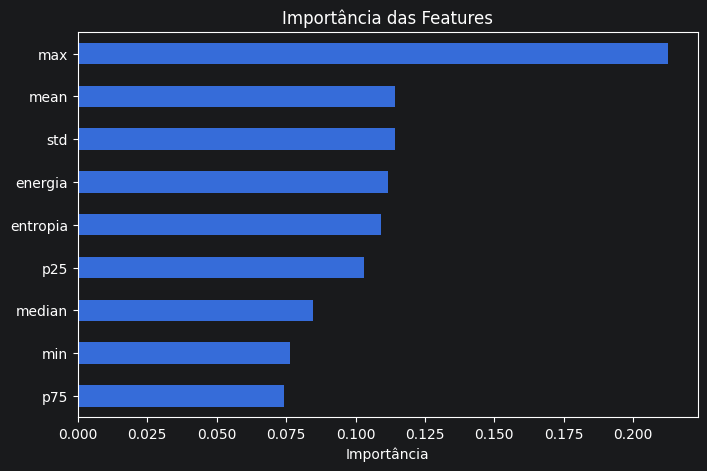

In [73]:
import matplotlib.pyplot as plt

importancias = pd.Series(
    rf_bal.feature_importances_,
    index=X.columns
)

importancias = importancias.sort_values()

plt.figure(figsize=(8,5))
importancias.plot(kind="barh")
plt.title("Importância das Features")
plt.xlabel("Importância")
plt.show()

In [74]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

knn = Pipeline([
    ("scaler", StandardScaler()),
    ("modelo", KNeighborsClassifier(n_neighbors=3))
])

knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)
prob_knn = knn.predict_proba(X_test)[:, 1]


def calcular_metricas(nome, y_real, y_pred, y_prob):
    cm = confusion_matrix(y_real, y_pred)
    tn, fp, fn, tp = cm.ravel()

    especificidade = tn / (tn + fp) if (tn + fp) > 0 else 0

    return {
        "modelo": nome,
        "acuracia": accuracy_score(y_real, y_pred),
        "precisao": precision_score(y_real, y_pred, zero_division=0),
        "recall_sensibilidade": recall_score(y_real, y_pred, zero_division=0),
        "especificidade": especificidade,
        "f1_score": f1_score(y_real, y_pred, zero_division=0),
        "auc_roc": roc_auc_score(y_real, y_prob)
    }

In [75]:
resultados_modelos = []

resultados_modelos.append(
    calcular_metricas(
        "Random Forest Balanceado",
        y_test,
        pred_bal,
        rf_bal.predict_proba(X_test)[:,1]
    )
)

resultados_modelos.append(
    calcular_metricas(
        "SVM Balanceado",
        y_test,
        pred_svm,
        prob_svm
    )
)

resultados_modelos.append(
    calcular_metricas(
        "KNN",
        y_test,
        pred_knn,
        prob_knn
    )
)

df_resultados = pd.DataFrame(
    resultados_modelos
)

df_resultados

,modelo,acuracia,precisao,recall_sensibilidade,especificidade,f1_score,auc_roc
0,Random Forest Balanceado,0.750000,1.000000,0.25,1.000,0.400000,0.640625
1,SVM Balanceado,0.416667,0.285714,0.50,0.375,0.363636,0.500000
2,KNN,0.666667,0.000000,0.00,1.000,0.000000,0.500000


In [76]:
from sklearn.svm import SVC

svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=42
)

svm.fit(
    X_train,
    y_train
)

pred_svm = svm.predict(X_test)
prob_svm = svm.predict_proba(X_test)[:,1]

/home/ana/PycharmProjects/Visao_Computacional/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


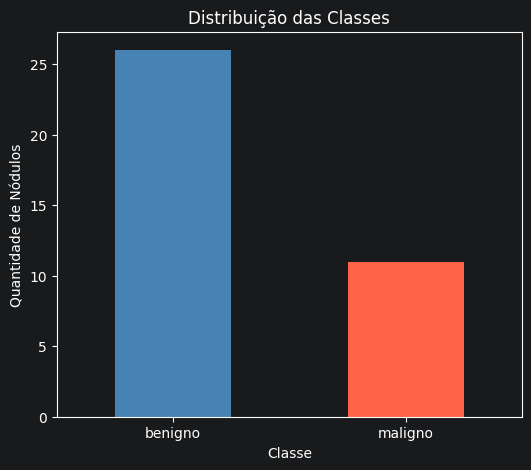

In [77]:
plt.figure(figsize=(6,5))

df_features["rotulo"].value_counts().plot(
    kind="bar",
    color=["steelblue", "tomato"]
)

plt.title("Distribuição das Classes")
plt.xlabel("Classe")
plt.ylabel("Quantidade de Nódulos")
plt.xticks(rotation=0)

plt.show()

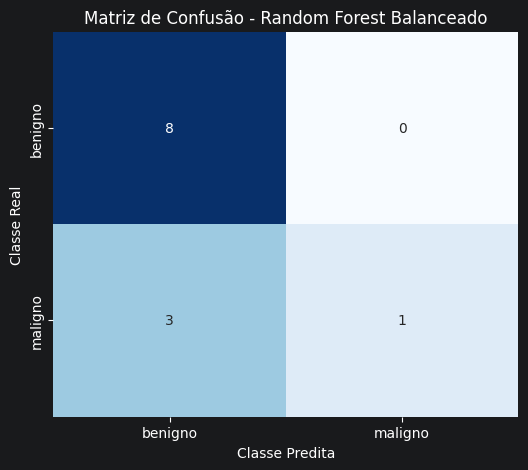

In [68]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, pred_bal)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_,
    cbar=False
)

plt.title("Matriz de Confusão - Random Forest Balanceado")
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")

plt.show()

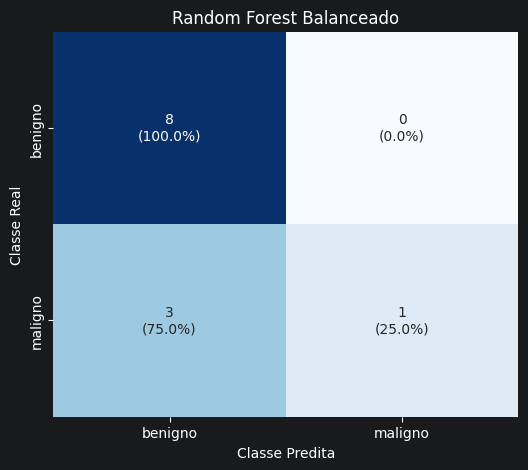

In [69]:
cm = confusion_matrix(y_test, pred_bal)

cm_percent = (
    cm.astype(float)
    / cm.sum(axis=1)[:, np.newaxis]
)

labels = np.array([
    [
        f"{cm[i,j]}\n({cm_percent[i,j]:.1%})"
        for j in range(cm.shape[1])
    ]
    for i in range(cm.shape[0])
])

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_,
    cbar=False
)

plt.title(
    "Random Forest Balanceado"
)

plt.xlabel(
    "Classe Predita"
)

plt.ylabel(
    "Classe Real"
)

plt.show()

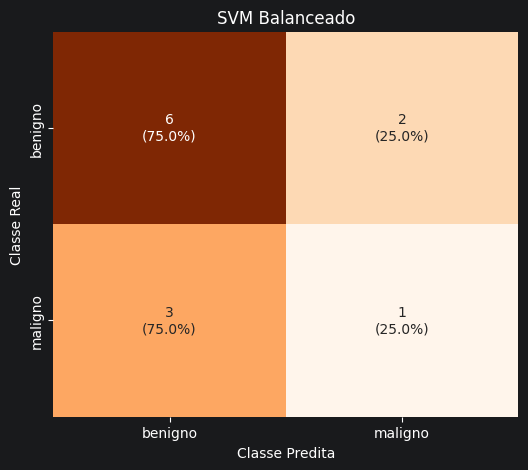

In [70]:
cm_svm = confusion_matrix(
    y_test,
    pred_svm
)

cm_percent = (
    cm_svm.astype(float)
    / cm_svm.sum(axis=1)[:, np.newaxis]
)

labels = np.array([
    [
        f"{cm_svm[i,j]}\n({cm_percent[i,j]:.1%})"
        for j in range(cm_svm.shape[1])
    ]
    for i in range(cm_svm.shape[0])
])

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_svm,
    annot=labels,
    fmt="",
    cmap="Oranges",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_,
    cbar=False
)

plt.title("SVM Balanceado")
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")

plt.show()

In [71]:
confusion_matrix(
    y_test,
    pred_knn
)

array([[8, 0],
       [4, 0]])

In [72]:
from sklearn.metrics import accuracy_score

for k in [1, 3, 5, 7]:

    knn = Pipeline([
        ("scaler", StandardScaler()),
        ("modelo", KNeighborsClassifier(
            n_neighbors=k
        ))
    ])

    knn.fit(
        X_train,
        y_train
    )

    pred = knn.predict(X_test)

    print(
        "k =", k,
        "->",
        accuracy_score(
            y_test,
            pred
        )
    )

    print(
        confusion_matrix(
            y_test,
            pred
        )
    )

    print()

k = 1 -> 0.5833333333333334
[[7 1]
 [4 0]]

k = 3 -> 0.6666666666666666
[[8 0]
 [4 0]]

k = 5 -> 0.6666666666666666
[[8 0]
 [4 0]]

k = 7 -> 0.6666666666666666
[[8 0]
 [4 0]]



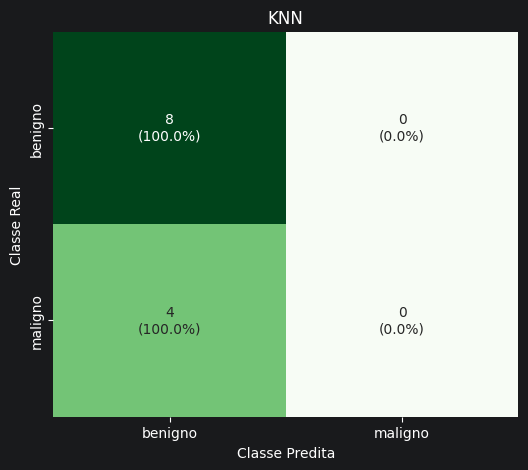

In [73]:
cm_knn = confusion_matrix(
    y_test,
    pred_knn
)

cm_percent = (
    cm_knn.astype(float)
    / cm_knn.sum(axis=1)[:, np.newaxis]
)

labels = np.array([
    [
        f"{cm_knn[i,j]}\n({cm_percent[i,j]:.1%})"
        for j in range(cm_knn.shape[1])
    ]
    for i in range(cm_knn.shape[0])
])

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_knn,
    annot=labels,
    fmt="",
    cmap="Greens",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_,
    cbar=False
)

plt.title("KNN")
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")

plt.show()

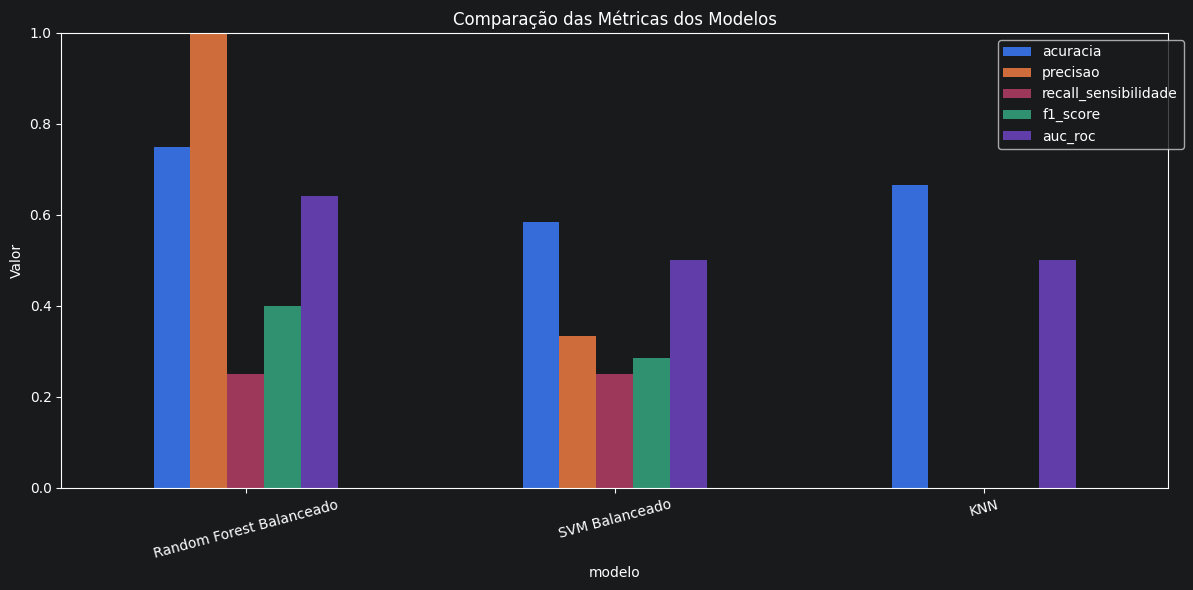

In [74]:
metricas = [
    "acuracia",
    "precisao",
    "recall_sensibilidade",
    "f1_score",
    "auc_roc"
]

fig, ax = plt.subplots(
    figsize=(12,6)
)

df_plot = df_resultados.set_index(
    "modelo"
)[metricas]

df_plot.plot(
    kind="bar",
    ax=ax
)

plt.title(
    "Comparação das Métricas dos Modelos"
)

plt.ylabel(
    "Valor"
)

plt.ylim(0,1)

plt.xticks(rotation=15)

plt.legend(
    bbox_to_anchor=(1.02,1)
)

plt.tight_layout()

plt.show()

In [76]:
print("RF:", rf_bal.predict_proba(X_test)[:3])
print("SVM:", svm.predict_proba(X_test)[:3])
print("KNN:", knn.predict_proba(X_test)[:3])

RF: [[0.665 0.335]
 [0.7   0.3  ]
 [0.625 0.375]]
SVM: [[0.65081685 0.34918315]
 [0.76459161 0.23540839]
 [0.66050608 0.33949392]]
KNN: [[0.85714286 0.14285714]
 [0.71428571 0.28571429]
 [0.85714286 0.14285714]]


In [78]:
from sklearn.metrics import roc_curve, roc_auc_score

prob_rf = rf_bal.predict_proba(X_test)[:,1]
prob_svm = svm.predict_proba(X_test)[:,1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, prob_rf)
fpr_svm, tpr_svm, _ = roc_curve(y_test, prob_svm)
fpr_knn, tpr_knn, _ = roc_curve(y_test, prob_knn)

auc_rf = roc_auc_score(y_test, prob_rf)
auc_svm = roc_auc_score(y_test, prob_svm)
auc_knn = roc_auc_score(y_test, prob_knn)

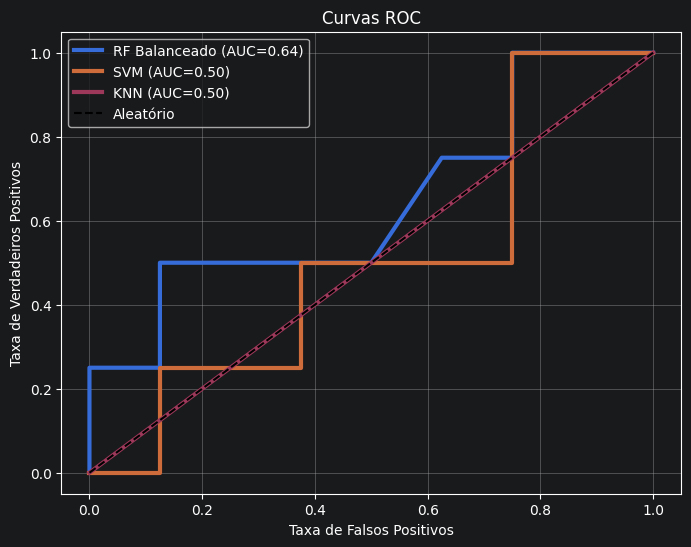

In [79]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr_rf,
    tpr_rf,
    linewidth=3,
    label=f"RF Balanceado (AUC={auc_rf:.2f})"
)

plt.plot(
    fpr_svm,
    tpr_svm,
    linewidth=3,
    label=f"SVM (AUC={auc_svm:.2f})"
)

plt.plot(
    fpr_knn,
    tpr_knn,
    linewidth=3,
    label=f"KNN (AUC={auc_knn:.2f})"
)

plt.plot(
    [0,1],
    [0,1],
    "k--",
    label="Aleatório"
)

plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.title("Curvas ROC")
plt.legend()
plt.grid()
plt.show()

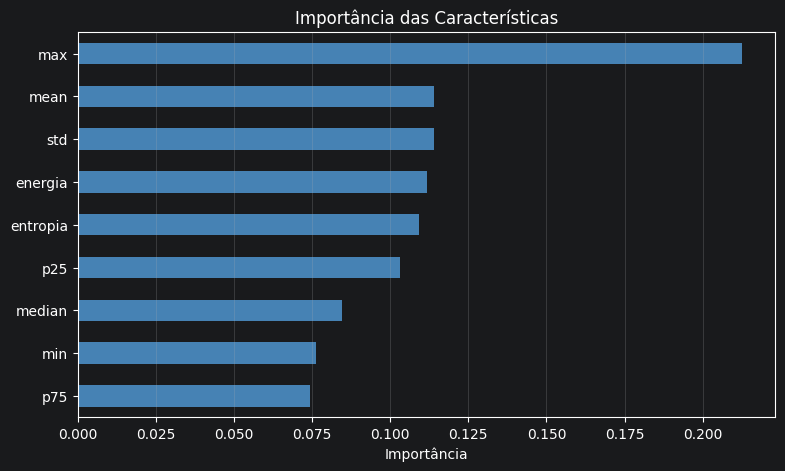

In [80]:
importancias = pd.Series(
    rf_bal.feature_importances_,
    index=X.columns
)

importancias = importancias.sort_values()

plt.figure(figsize=(9,5))

importancias.plot(
    kind="barh",
    color="steelblue"
)

plt.title("Importância das Características")
plt.xlabel("Importância")
plt.grid(axis="x", alpha=0.3)

plt.show()

In [84]:
print(scan.patient_id)
print(len(clusters))


LIDC-IDRI-0078
4


# Construção dos quatro cenários de consenso

In [92]:
def converter_classes(cluster):
    malignidades = [ann.malignancy for ann in cluster]
    malignidades = [m for m in malignidades if m != 3]

    classes = []

    for m in malignidades:
        if m in [1, 2]:
            classes.append("benigno")
        elif m in [4, 5]:
            classes.append("maligno")

    return classes


def obter_rotulo_por_cenario(cluster, minimo_concordancia):
    classes = converter_classes(cluster)

    if len(classes) == 0:
        return None

    qtd_benigno = classes.count("benigno")
    qtd_maligno = classes.count("maligno")

    if minimo_concordancia == "total":
        if len(classes) == len(cluster) and len(set(classes)) == 1:
            return classes[0]
        return None

    if qtd_benigno >= minimo_concordancia and qtd_benigno > qtd_maligno:
        return "benigno"

    if qtd_maligno >= minimo_concordancia and qtd_maligno > qtd_benigno:
        return "maligno"

    return None

In [93]:
for i, cluster in enumerate(clusters):
    print(f"Nódulo {i}")
    print("Cenário 1:", obter_rotulo_por_cenario(cluster, 1))
    print("Cenário 2:", obter_rotulo_por_cenario(cluster, 2))
    print("Cenário 3:", obter_rotulo_por_cenario(cluster, 3))
    print("Cenário 4:", obter_rotulo_por_cenario(cluster, "total"))
    print()

Nódulo 0
Cenário 1: maligno
Cenário 2: maligno
Cenário 3: None
Cenário 4: None

Nódulo 1
Cenário 1: maligno
Cenário 2: maligno
Cenário 3: None
Cenário 4: None

Nódulo 2
Cenário 1: benigno
Cenário 2: None
Cenário 3: None
Cenário 4: benigno

Nódulo 3
Cenário 1: maligno
Cenário 2: maligno
Cenário 3: maligno
Cenário 4: None



In [94]:
cenario1 = []
cenario2 = []
cenario3 = []
cenario4 = []

In [95]:
for scan in scans:

    nodulos = scan.cluster_annotations()

    for cluster in nodulos:

        centroide = cluster[0].centroid.astype(int)

        x = int(centroide[0])
        y = int(centroide[1])
        z = int(centroide[2])

        paciente = scan.patient_id

        rot1 = obter_rotulo_por_cenario(cluster, 1)
        rot2 = obter_rotulo_por_cenario(cluster, 2)
        rot3 = obter_rotulo_por_cenario(cluster, 3)
        rot4 = obter_rotulo_por_cenario(cluster, "total")

        if rot1 is not None:
            cenario1.append(
                [paciente, x, y, z, rot1]
            )

        if rot2 is not None:
            cenario2.append(
                [paciente, x, y, z, rot2]
            )

        if rot3 is not None:
            cenario3.append(
                [paciente, x, y, z, rot3]
            )

        if rot4 is not None:
            cenario4.append(
                [paciente, x, y, z, rot4]
            )

Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some n

In [96]:
print("Cenário 1:", len(cenario1))
print("Cenário 2:", len(cenario2))
print("Cenário 3:", len(cenario3))
print("Cenário 4:", len(cenario4))

Cenário 1: 1983
Cenário 2: 1029
Cenário 3: 437
Cenário 4: 805


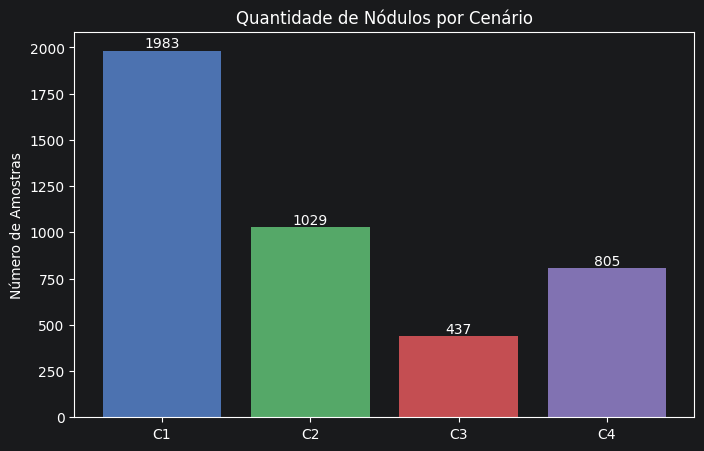

In [97]:
cenarios = {
    "C1": len(cenario1),
    "C2": len(cenario2),
    "C3": len(cenario3),
    "C4": len(cenario4)
}

plt.figure(figsize=(8,5))

bars = plt.bar(
    cenarios.keys(),
    cenarios.values(),
    color=[
        "#4c72b0",
        "#55a868",
        "#c44e52",
        "#8172b2"
    ]
)

plt.title(
    "Quantidade de Nódulos por Cenário"
)

plt.ylabel(
    "Número de Amostras"
)

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        int(y),
        ha="center",
        va="bottom"
    )

plt.show()

In [98]:
colunas = [
    "paciente",
    "x",
    "y",
    "z",
    "rotulo"
]

df_c1 = pd.DataFrame(cenario1, columns=colunas)
df_c2 = pd.DataFrame(cenario2, columns=colunas)
df_c3 = pd.DataFrame(cenario3, columns=colunas)
df_c4 = pd.DataFrame(cenario4, columns=colunas)

print(df_c1.shape)
print(df_c2.shape)
print(df_c3.shape)
print(df_c4.shape)

(1983, 5)
(1029, 5)
(437, 5)
(805, 5)


In [99]:
def construir_features(df):

    dados = []

    for _, linha in df.iterrows():

        try:

            volume = carregar_volume_paciente(
                linha["paciente"]
            )

            if volume is None:
                continue

            x = int(linha["x"])
            y = int(linha["y"])
            z = int(linha["z"])

            if z >= volume.shape[0]:
                continue

            f = extrair_features(
                volume,
                x,
                y,
                z
            )

            if f is None:
                continue

            f["rotulo"] = linha["rotulo"]

            dados.append(f)

        except:
            continue

    return pd.DataFrame(dados)

In [ ]:
df_feat_c1 = construir_features(
    df_c1.sample(
        200,
        random_state=42
    )
)

print(df_feat_c1.shape)
df_feat_c1.head()

ImageSeriesReader (0x1b562020): Non uniform sampling or missing slices detected,  maximum nonuniformity:1.24532



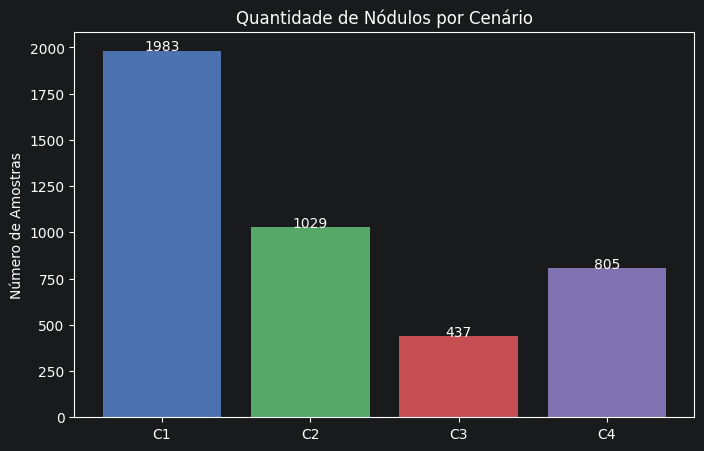

In [1]:
cenarios = {
    "C1": 1983,
    "C2": 1029,
    "C3": 437,
    "C4": 805
}

plt.figure(figsize=(8,5))

bars = plt.bar(
    cenarios.keys(),
    cenarios.values(),
    color=[
        "#4c72b0",
        "#55a868",
        "#c44e52",
        "#8172b2"
    ]
)

plt.title(
    "Quantidade de Nódulos por Cenário"
)

plt.ylabel(
    "Número de Amostras"
)

for bar in bars:
    y = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        y,
        int(y),
        ha="center"
    )

plt.show()

In [80]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)
prob_gb = gb.predict_proba(X_test)[:, 1]

In [82]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

print(
    "Acurácia:",
    accuracy_score(
        y_test,
        pred_gb
    )
)

print()

print(
    confusion_matrix(
        y_test,
        pred_gb
    )
)

print()

print(
    classification_report(
        y_test,
        pred_gb,
        target_names=encoder.classes_,
        zero_division=0
    )
)

Acurácia: 0.75

[[7 1]
 [2 2]]

              precision    recall  f1-score   support

     benigno       0.78      0.88      0.82         8
     maligno       0.67      0.50      0.57         4

    accuracy                           0.75        12
   macro avg       0.72      0.69      0.70        12
weighted avg       0.74      0.75      0.74        12



In [84]:
resultados_modelos = []

resultados_modelos.append(
    calcular_metricas(
        "Random Forest Balanceado",
        y_test,
        pred_bal,
        prob_rf
    )
)

resultados_modelos.append(
    calcular_metricas(
        "SVM Balanceado",
        y_test,
        pred_svm,
        prob_svm
    )
)

resultados_modelos.append(
    calcular_metricas(
        "KNN",
        y_test,
        pred_knn,
        prob_knn
    )
)

resultados_modelos.append(
    calcular_metricas(
        "Gradient Boosting",
        y_test,
        pred_gb,
        prob_gb
    )
)

df_resultados = pd.DataFrame(
    resultados_modelos
)

df_resultados

,modelo,acuracia,precisao,recall_sensibilidade,especificidade,f1_score,auc_roc
0,Random Forest Balanceado,0.750000,1.000000,0.25,1.000,0.400000,0.640625
1,SVM Balanceado,0.583333,0.333333,0.25,0.750,0.285714,0.500000
2,KNN,0.666667,0.000000,0.00,1.000,0.000000,0.500000
3,Gradient Boosting,0.750000,0.666667,0.50,0.875,0.571429,0.718750


In [85]:
cm_gb = confusion_matrix(
    y_test,
    pred_gb
)

print(cm_gb)

[[7 1]
 [2 2]]


In [87]:
import seaborn as sns

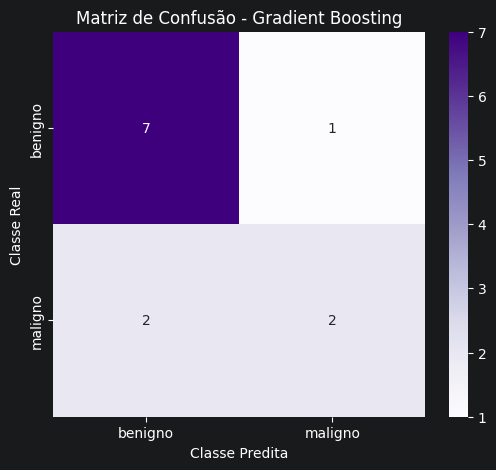

In [88]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_gb,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title(
    "Matriz de Confusão - Gradient Boosting"
)

plt.xlabel(
    "Classe Predita"
)

plt.ylabel(
    "Classe Real"
)

plt.show()

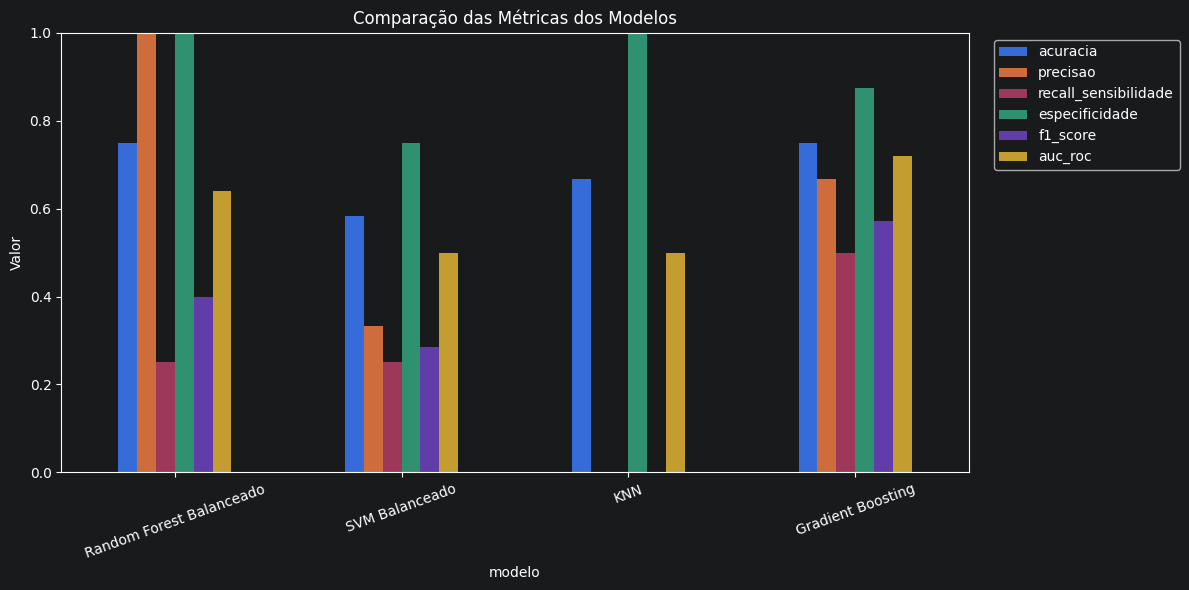

In [89]:
metricas = [
    "acuracia",
    "precisao",
    "recall_sensibilidade",
    "especificidade",
    "f1_score",
    "auc_roc"
]

df_plot = df_resultados.set_index(
    "modelo"
)[metricas]

df_plot.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title(
    "Comparação das Métricas dos Modelos"
)

plt.ylabel("Valor")
plt.ylim(0,1)
plt.xticks(rotation=20)
plt.legend(
    bbox_to_anchor=(1.02,1)
)

plt.tight_layout()
plt.show()

In [90]:
def classificar_nodulos(
    volume,
    lista_coordenadas,
    modelo,
    encoder
):
    resultado = {
        "exame": "tomografia",
        "nodulos": []
    }

    for nodulo in lista_coordenadas:

        x = int(nodulo["x"])
        y = int(nodulo["y"])
        z = int(nodulo["z"])

        f = extrair_features(
            volume,
            x,
            y,
            z
        )

        if f is None:
            continue

        X_pred = pd.DataFrame([f])

        pred = modelo.predict(X_pred)[0]

        prob = modelo.predict_proba(
            X_pred
        )[0]

        classe = encoder.inverse_transform(
            [pred]
        )[0]

        resultado["nodulos"].append(
            {
                "id": nodulo["id"],
                "coordenada": {
                    "x": x,
                    "y": y,
                    "z": z
                },
                "classe_predita": classe,
                "probabilidade":
                    float(np.max(prob))
            }
        )

    return resultado

In [91]:
teste = classificar_nodulos(
    volume,
    [
        {
            "id":"nodulo_1",
            "x":311,
            "y":330,
            "z":25
        },
        {
            "id":"nodulo_2",
            "x":348,
            "y":336,
            "z":47
        }
    ],
    gb,
    encoder
)

teste

{'exame': 'tomografia',
 'nodulos': [{'id': 'nodulo_1',
   'coordenada': {'x': 311, 'y': 330, 'z': 25},
   'classe_predita': 'maligno',
   'probabilidade': 0.9984294582924332},
  {'id': 'nodulo_2',
   'coordenada': {'x': 348, 'y': 336, 'z': 47},
   'classe_predita': 'maligno',
   'probabilidade': 0.9673144102983452}]}

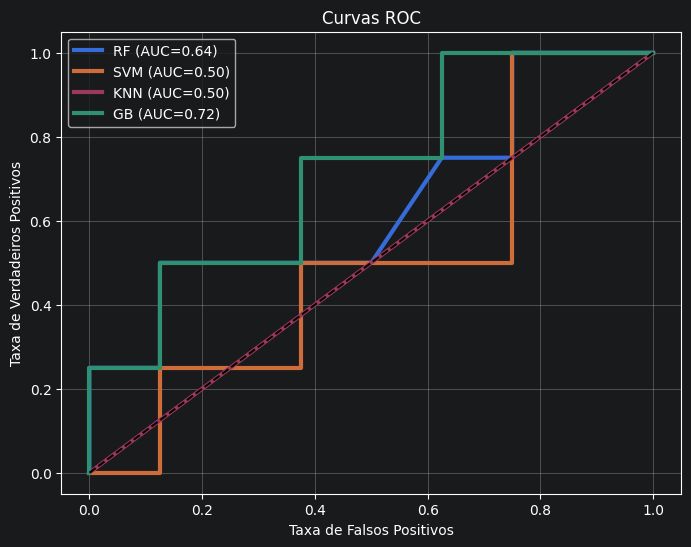

In [92]:
fpr_gb, tpr_gb, _ = roc_curve(y_test, prob_gb)
auc_gb = roc_auc_score(y_test, prob_gb)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_rf,
    tpr_rf,
    linewidth=3,
    label=f"RF (AUC={auc_rf:.2f})"
)

plt.plot(
    fpr_svm,
    tpr_svm,
    linewidth=3,
    label=f"SVM (AUC={auc_svm:.2f})"
)

plt.plot(
    fpr_knn,
    tpr_knn,
    linewidth=3,
    label=f"KNN (AUC={auc_knn:.2f})"
)

plt.plot(
    fpr_gb,
    tpr_gb,
    linewidth=3,
    label=f"GB (AUC={auc_gb:.2f})"
)

plt.plot([0,1],[0,1],"k--")

plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.title("Curvas ROC")
plt.legend()
plt.grid()

plt.show()

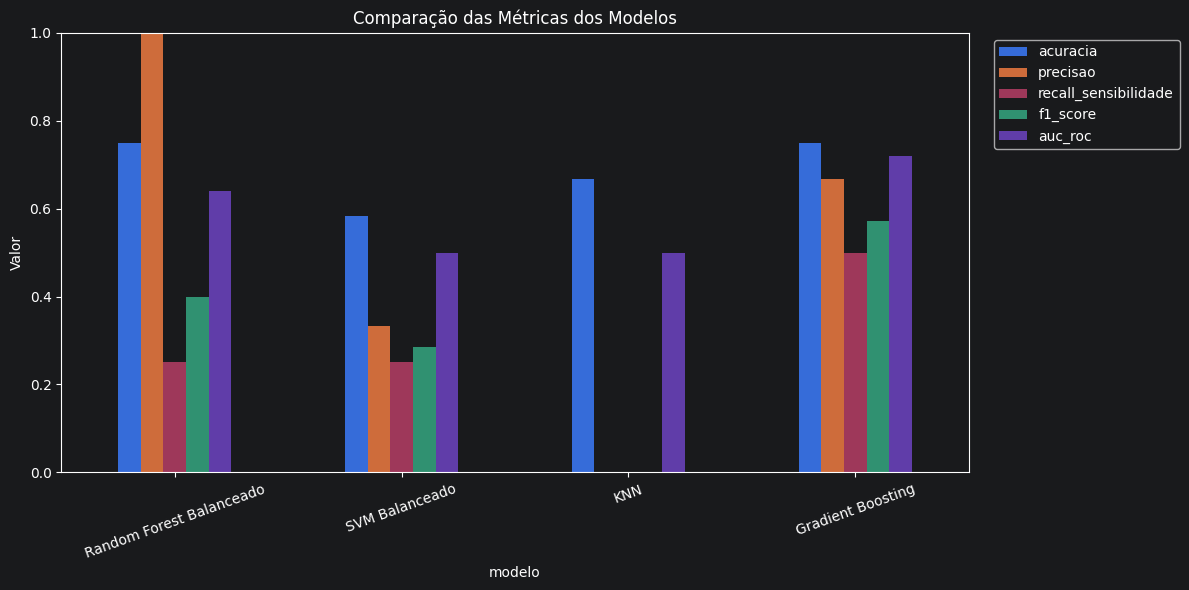

In [93]:
df_plot = df_resultados.set_index(
    "modelo"
)[
    [
        "acuracia",
        "precisao",
        "recall_sensibilidade",
        "f1_score",
        "auc_roc"
    ]
]

df_plot.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title(
    "Comparação das Métricas dos Modelos"
)

plt.ylabel("Valor")
plt.ylim(0,1)
plt.xticks(rotation=20)

plt.legend(
    bbox_to_anchor=(1.02,1)
)

plt.tight_layout()
plt.show()

In [94]:
import pylidc as pl
from collections import Counter

benignos = 0
malignos = 0
indeterminados = 0

scans = pl.query(pl.Scan).all()

for scan in scans:
    nodulos = scan.cluster_annotations()

    for nodulo in nodulos:

        malignidades = []

        for ann in nodulo:
            score = ann.malignancy

            if score in [1, 2]:
                malignidades.append("benigno")

            elif score in [4, 5]:
                malignidades.append("maligno")

            else:
                malignidades.append("indeterminado")

        contagem = Counter(malignidades)

        # mesma regra do trabalho:
        if contagem["maligno"] > contagem["benigno"]:
            malignos += 1

        elif contagem["benigno"] > contagem["maligno"]:
            benignos += 1

        else:
            indeterminados += 1

print(f"Benignos: {benignos}")
print(f"Malignos: {malignos}")
print(f"Indeterminados: {indeterminados}")
print(f"Total: {benignos + malignos + indeterminados}")

Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some n

In [95]:
import pylidc as pl
import pandas as pd
from collections import Counter

resultado = {
    "Cenário": [],
    "Benignos": [],
    "Malignos": [],
    "Total": []
}

c1_b = c1_m = 0
c2_b = c2_m = 0
c3_b = c3_m = 0
c4_b = c4_m = 0

scans = pl.query(pl.Scan).all()

for scan in scans:

    nodulos = scan.cluster_annotations()

    for nodulo in nodulos:

        votos = []

        for ann in nodulo:

            m = ann.malignancy

            if m in [1, 2]:
                votos.append("benigno")

            elif m in [4, 5]:
                votos.append("maligno")

        # ignora nódulos sem votos válidos
        if len(votos) == 0:
            continue

        cont = Counter(votos)

        n_b = cont["benigno"]
        n_m = cont["maligno"]
        n_total = n_b + n_m

        #################################################
        # Cenário 1
        #################################################
        if n_b > 0:
            c1_b += 1
        elif n_m > 0:
            c1_m += 1

        #################################################
        # Cenário 2
        #################################################
        if n_b >= 2:
            c2_b += 1
        elif n_m >= 2:
            c2_m += 1

        #################################################
        # Cenário 3
        #################################################
        if n_b >= 3:
            c3_b += 1
        elif n_m >= 3:
            c3_m += 1

        #################################################
        # Cenário 4
        #################################################
        if n_total > 0:

            if n_b == n_total:
                c4_b += 1

            elif n_m == n_total:
                c4_m += 1

Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some nodules may be close and must be grouped manually.
Failed to reduce all groups to <= 4 Annotations.
Some n

In [96]:
df = pd.DataFrame({
    "Cenário":
        ["C1", "C2", "C3", "C4"],

    "Benignos":
        [c1_b, c2_b, c3_b, c4_b],

    "Malignos":
        [c1_m, c2_m, c3_m, c4_m]
})

df["Total"] = (
    df["Benignos"] +
    df["Malignos"]
)

df

,Cenário,Benignos,Malignos,Total
0,C1,1698,463,2161
1,C2,601,447,1048
2,C3,212,225,437
3,C4,1261,463,1724


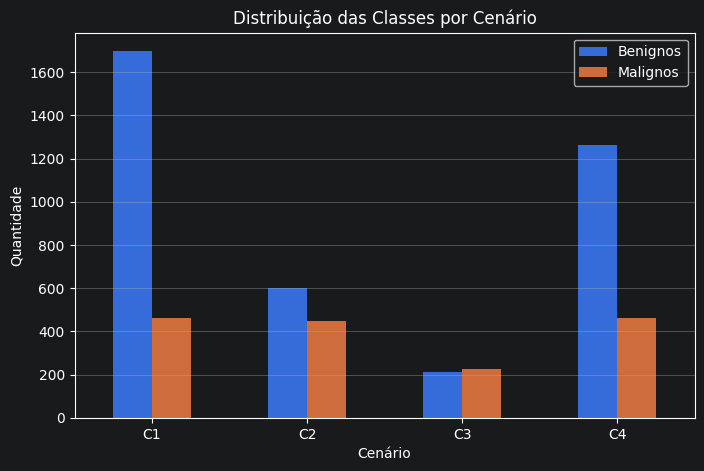

In [97]:
import matplotlib.pyplot as plt

df.set_index("Cenário")[
    ["Benignos", "Malignos"]
].plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("Quantidade")
plt.title(
    "Distribuição das Classes por Cenário"
)

plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

In [100]:
%whos

Variable                     Type                          Data/Info
--------------------------------------------------------------------
BASE_DICOM                   str                           /home/ana/PycharmProjects<...>l/presentation3/lidc_idri
Counter                      type                          <class 'collections.Counter'>
GradientBoostingClassifier   ABCMeta                       <class 'sklearn.ensemble.<...>dientBoostingClassifier'>
KNeighborsClassifier         ABCMeta                       <class 'sklearn.neighbors<...>on.KNeighborsClassifier'>
LabelEncoder                 type                          <class 'sklearn.preproces<...>ing._label.LabelEncoder'>
Pipeline                     ABCMeta                       <class 'sklearn.pipeline.Pipeline'>
RandomForestClassifier       ABCMeta                       <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
SVC                          ABCMeta                       <class 'sklearn.svm._classes.SVC'>
StandardS

In [101]:
print(construir_dataset_scan)

<function construir_dataset_scan at 0x774d68c5e020>
